# Testing Exact and JAX-based Gradient Computation for t-SNE Loss with Respect to Alpha

## Overview

This notebook shows two approaches to compute the gradient of the t-SNE loss function (KL divergence) with respect to the degree-of-freedom parameter (α). The gradient is critical for optimizing α, enabling finer control over the embedding process. The methods are compared to each other to check for consistancy

1. Exact Gradient Computation (compute_gradient_alpha_exact)

**Purpose:** Computes the exact gradient of the t-SNE KL divergence with respect to α using the closed-form mathematical expression. The derivation see below. 

**Key steps:**
The imlementation is straightforward and is step-by-step applying the derived formula for the gradient

**Advantages:**

* Provides exact results, ensuring precision in gradient-based optimization.
* Straightforward implementation with no external dependencies.

**Drawbacks:**

* Computationally intensive for large datasets due to $$\mathcal{O}(n^2)$$complexity from pairwise distance calculations.

2. JAX-Based Gradient Computation (gradient_alpha_jax)

**Purpose:** Computes the gradient using automatic differentiation via JAX, leveraging its ability to symbolically compute gradients of functions.

**Key Steps:**

* Defines a gradient function alpha_grad_jax using JAX's grad function, which calculates the gradient of the KL divergence with respect to α.
The constistancy of the KL-divergence values between those computed by openTSNE and the manual implementation is tested in beforehand.
* Passes the affinities, squared distances, and α to compute the gradient using the symbolic differentiation of KL_divergence_exact.

**Advantages:**

* Highly flexible and modular, as JAX can differentiate through arbitrary operations within the KL divergence function.
* More efficient memory management for large datasets due to JAX's just-in-time (JIT) compilation and GPU/TPU support.

**Drawbacks:**

* Requires installation and familiarity with JAX, adding an external dependency.
* Computational overhead for JIT compilation may not benefit small datasets.

## Derivation of the Gradient $\displaystyle \frac{\partial L}{\partial \alpha}$

#### We are given the loss function:

$$
L = -\sum_{i,j} p_{i,j} \log \left( \frac{\left(1 + \dfrac{d_{i,j}^2}{\alpha}\right)^{-\alpha}}{\displaystyle \sum_{k \ne \ell} \left(1 + \dfrac{d_{k,\ell}^2}{\alpha}\right)^{-\alpha}} \right)
$$

#### Our goal is to compute the gradient $\displaystyle \frac{\partial L}{\partial \alpha}$.

### Step 1: Simplify the Loss Function

#### Let:

$$
\begin{align*}
s_{i,j} &= 1 + \dfrac{d_{i,j}^2}{\alpha}, \\
y_{i,j} &= s_{i,j}^{-\alpha}, \\
Z &= \sum_{k \ne \ell} y_{k,\ell}, \\
q_{i,j} &= \dfrac{y_{i,j}}{Z}.
\end{align*}
$$

#### Then, the loss function becomes:

$$
L = -\sum_{i,j} p_{i,j} \left( \log y_{i,j} - \log Z \right) = -\sum_{i,j} p_{i,j} \log y_{i,j} + \log Z.
$$

### Step 2: Compute the Gradient $\displaystyle \frac{\partial L}{\partial \alpha}$

#### The gradient is:

$$
\frac{\partial L}{\partial \alpha} = -\sum_{i,j} p_{i,j} \frac{\partial \log y_{i,j}}{\partial \alpha} + \frac{\partial \log Z}{\partial \alpha}.
$$

## Step 3: Compute $\displaystyle \frac{\partial \log y_{i,j}}{\partial \alpha}$

#### Since:

$$
\log y_{i,j} = -\alpha \log s_{i,j},
$$

#### we have:

$$
\frac{\partial \log y_{i,j}}{\partial \alpha} = -\log s_{i,j} - \alpha \frac{\partial \log s_{i,j}}{\partial \alpha}.
$$

#### But:

$$
\frac{\partial \log s_{i,j}}{\partial \alpha} = \frac{\partial}{\partial \alpha} \left( \log \left(1 + \frac{d_{i,j}^2}{\alpha} \right) \right) = -\frac{d_{i,j}^2}{\alpha^2 s_{i,j}}.
$$

#### Therefore:

$$
\frac{\partial \log y_{i,j}}{\partial \alpha} = -\log s_{i,j} + \frac{\alpha d_{i,j}^2}{\alpha^2 s_{i,j}} = -\log s_{i,j} + \frac{d_{i,j}^2}{\alpha s_{i,j}}.
$$

#### Simplify:

$$
\frac{\partial \log y_{i,j}}{\partial \alpha} = -\log s_{i,j} + \frac{d_{i,j}^2}{\alpha + d_{i,j}^2}.
$$

### Step 4: Compute $\displaystyle \frac{\partial \log Z}{\partial \alpha}$

#### Since $Z = \sum_{k \ne \ell} y_{k,\ell}$, we have:

$$
\frac{\partial \log Z}{\partial \alpha} = \frac{1}{Z} \frac{\partial Z}{\partial \alpha} = \frac{1}{Z} \sum_{k \ne \ell} \frac{\partial y_{k,\ell}}{\partial \alpha}.
$$

#### But:

$$
\frac{\partial y_{k,\ell}}{\partial \alpha} = y_{k,\ell} \left( -\log s_{k,\ell} + \frac{d_{k,\ell}^2}{\alpha + d_{k,\ell}^2} \right).
$$

#### So:

$$
\frac{\partial \log Z}{\partial \alpha} = \sum_{k \ne \ell} q_{k,\ell} \left( -\log s_{k,\ell} + \frac{d_{k,\ell}^2}{\alpha + d_{k,\ell}^2} \right).
$$

### Step 5: Combine the Terms

#### Putting it all together:

$$
\begin{align*}
\frac{\partial L}{\partial \alpha} &= -\sum_{i,j} p_{i,j} \left( -\log s_{i,j} + \frac{d_{i,j}^2}{\alpha + d_{i,j}^2} \right) + \sum_{k \ne \ell} q_{k,\ell} \left( -\log s_{k,\ell} + \frac{d_{k,\ell}^2}{\alpha + d_{k,\ell}^2} \right) \\
&= \sum_{i,j} (p_{i,j} - q_{i,j}) \left( \log s_{i,j} - \frac{d_{i,j}^2}{\alpha + d_{i,j}^2} \right).
\end{align*}
$$

### Final Expression

#### Therefore, the gradient is:

$$
\boxed{\frac{\partial L}{\partial \alpha} = \sum_{i,j} \left( p_{i,j} - q_{i,j} \right) \left( \log \left( 1 + \dfrac{d_{i,j}^2}{\alpha} \right) - \dfrac{d_{i,j}^2}{\alpha + d_{i,j}^2} \right)}.
$$

In [7]:
import numpy as np 

from sklearn.datasets import make_swiss_roll
import matplotlib.pyplot as plt
import seaborn as sns
import importlib

from python_tsne_utils import utils 

importlib.reload(utils)

<module 'python_tsne_utils.utils' from '/Users/a1/Documents/t-SNE-project/optsne/python_tsne_utils/utils.py'>

### Load toy-data, initialize embedding

In [2]:
X, colors = make_swiss_roll(n_samples=500, random_state=0)

In [3]:
initial_embedding, affinities = utils.initialize_tsne_embedding(X = X, initial_alpha=1)
affinity_matrix = np.asarray(affinities)

Computing the affinity matrix...
Performing the PCA initialization...
Initializing the t-SNE embedding...


### First, we check the consistency between the KL values returned by openTSNE and our implementation.
### Then, we use the KL calculation function to compute the gradient with respect to alpha using JAX and compare it to our exact computation implementation.

In [4]:
test_alpha = 1. # JAX requires float32
exact_kls = []
openTSNE_kls = []
exact_alpha_grads = []
jax_alpha_grads = []


for i in range(10):
        
    initial_embedding.optimize(n_iter = 1, inplace = True, dof = test_alpha)
    Q, squred_dist, sum_Q = utils.compute_low_dim_affinities_exact(Y = initial_embedding, α = test_alpha)
    
    
    kl_exact = utils.KL_divergence_exact(alpha = test_alpha, p_ij=affinities, d_squared = squred_dist) # custom implementation
    exact_kls.append(kl_exact)
    
    kl_openTSNE = initial_embedding.kl_divergence # buit-in openTSNE method
    openTSNE_kls.append(kl_openTSNE)    
    print(f"KL exact: {kl_exact}, KL openTSNE: {kl_openTSNE}")
    
    alpha_grad_exact = utils.compute_gradient_alpha_exact(p=affinities, d_squared=squred_dist, α=test_alpha) # exact gradient computation
    exact_alpha_grads.append(alpha_grad_exact)
    alpha_grad_jax = utils.gradient_alpha_jax(α=test_alpha, square_distances=squred_dist, affinities=affinity_matrix) # jax gradient computation
    jax_alpha_grads.append(alpha_grad_jax)
    print(f"Alpha grad exact: {alpha_grad_exact}, Alpha grad jax: {alpha_grad_jax}")    

KL exact: 2.778367519378662, KL openTSNE: 2.7777405249625815
Alpha grad exact: -3.774192422095342e-09, Alpha grad jax: -3.767581802094355e-09
KL exact: 2.778367280960083, KL openTSNE: 2.778032256007963
Alpha grad exact: -8.050153261514757e-09, Alpha grad jax: -8.048459676501807e-09
KL exact: 2.7783570289611816, KL openTSNE: 2.7783595254260334
Alpha grad exact: -2.58711876214522e-09, Alpha grad jax: -2.586602931842208e-09
KL exact: 2.778252601623535, KL openTSNE: 2.778201177114891
Alpha grad exact: -1.2360689944767663e-08, Alpha grad jax: -1.236185198649764e-08
KL exact: 2.7769834995269775, KL openTSNE: 2.777011793349457
Alpha grad exact: -1.7719579249747568e-06, Alpha grad jax: -1.7759157344698906e-06
KL exact: 2.760108232498169, KL openTSNE: 2.7604266672955653
Alpha grad exact: -0.00029943473579251666, Alpha grad jax: -0.00030005164444446564
KL exact: 2.57314395904541, KL openTSNE: 2.5748055814188717
Alpha grad exact: -0.029247384844171952, Alpha grad jax: -0.029320701956748962
KL exa

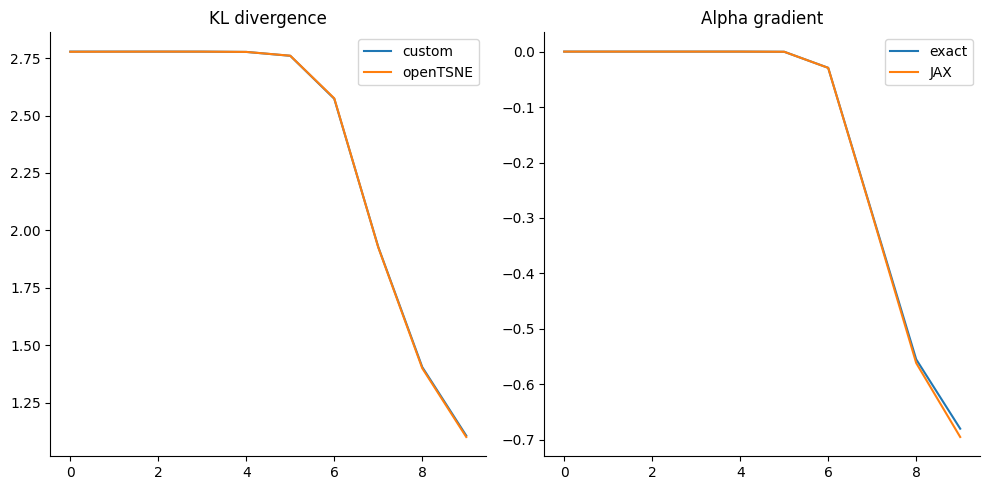

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].plot(exact_kls, label='custom')
ax[0].plot(openTSNE_kls, label='openTSNE')
ax[0].x_label = 'Iteration'
ax[0].y_label = 'KL divergence'
ax[0].set_title('KL divergence')
ax[0].legend()

ax[1].plot(exact_alpha_grads, label='exact')
ax[1].plot(jax_alpha_grads, label='JAX')
ax[1].set_title('Alpha gradient')
ax[1].x_label = 'Iteration'
ax[1].y_label = 'Gradient'
ax[1].legend()
plt.tight_layout()
sns.despine()
plt.show()